# Experiment 3 — Missing Values and Representation Robustness

This notebook investigates how different machine learning models respond to degraded data quality in the form of missing values.

The purpose of the experiment is to examine whether preprocessing and feature engineering can compensate for incomplete representations and whether different inductive biases exhibit different levels of robustness under missing-data conditions.

The experiment compares:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

under controlled missing-value conditions.

Personally, I find missing values particularly interesting because they represent one of the most common real-world data quality problems in practical machine learning workflows. At the same time, missing data can fundamentally alter the information available to a model, making this experiment especially relevant when discussing representation quality and inductive bias.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, experiment execution, visualization, and result saving.

In [2]:
from src.data.load_data import (
    load_adult_dataset
)

from src.experiments.missingness import (
    run_missingness_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Missing Value Configurations

The experiment evaluates multiple missing-value conditions in order to examine how model robustness changes as representation quality deteriorates.

Two degradation levels are examined:
- 10% missing values
- 30% missing values

This staged setup allows the analysis to investigate whether preprocessing effectiveness changes as missing-data severity increases.

In [4]:
import pandas as pd

missing_configs = {
    "10% Missing": 0.1,
    "30% Missing": 0.3
}

all_results = []

for config_name, missing_fraction in missing_configs.items():
    
    print(f"\nRunning configuration: {config_name}")
    
    temp_results = run_missingness_experiment(
        X,
        y,
        missing_fraction=missing_fraction
    )
    
    temp_results["missingness"] = config_name
    
    all_results.append(temp_results)

results_df = pd.concat(
    all_results,
    ignore_index=True
)

results_df


Running configuration: 10% Missing



=== Raw Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...



=== Cleaned Preprocessing ===
Training Logistic Regression...


...


=== Engineered Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc,missingness
0,Raw,Logistic Regression,0.780326,0.380127,0.611390,10% Missing
1,Raw,Decision Tree,0.808373,0.606061,0.743619,10% Missing
2,Raw,Naive Bayes,0.792097,0.392825,0.824483,10% Missing
3,Raw,MLP,0.293684,0.402908,0.586473,10% Missing
4,Cleaned,Logistic Regression,0.798239,0.666667,0.895680,10% Missing
5,Cleaned,Decision Tree,0.808271,0.606099,0.743724,10% Missing
6,Cleaned,Naive Bayes,0.607943,0.529715,0.825724,10% Missing
7,Cleaned,MLP,0.821271,0.650100,0.873954,10% Missing
8,Engineered,Logistic Regression,0.788515,0.652890,0.887355,10% Missing
9,Engineered,Decision Tree,0.801924,0.590823,0.735090,10% Missing


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [5]:
save_metrics(
    results_df,
    "missingness_results.csv"
)

Metrics saved to: ../results/metrics/missingness_results.csv


## Missing Values Performance Visualization

The following figure compares model performance across preprocessing levels under missing-value degradation conditions.

Plot saved to: ../results/plots/missingness_f1_comparison.png


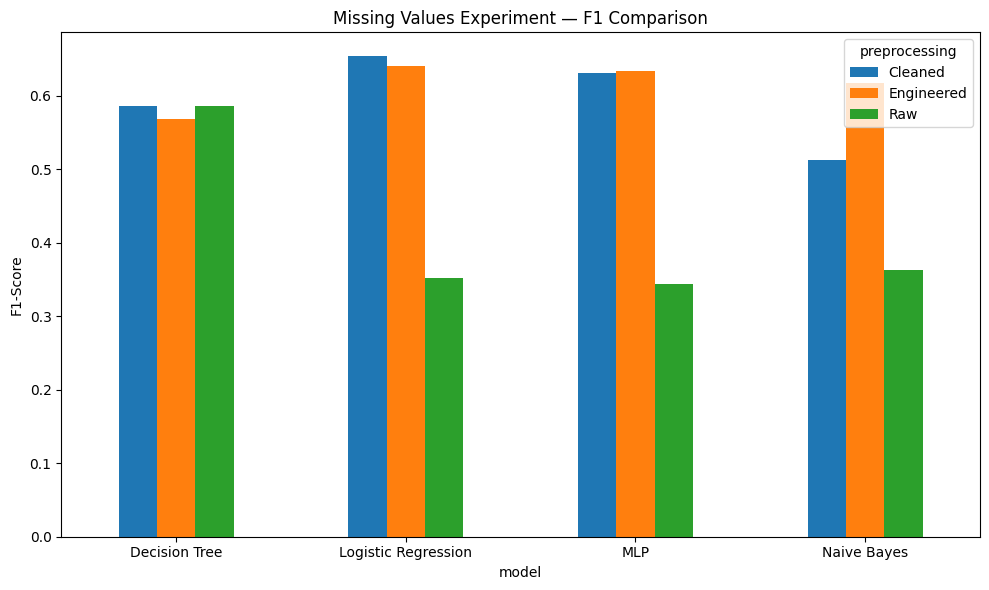

In [6]:
plot_f1_comparison(
    results_df,
    title="Missing Values Experiment — F1 Comparison",
    filename="missingness_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [7]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="missingness_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/missingness_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.586467
1,Decision Tree,Engineered,0.567941
2,Decision Tree,Raw,0.586328
3,Logistic Regression,Cleaned,0.653723
4,Logistic Regression,Engineered,0.639985
5,Logistic Regression,Raw,0.352101
6,MLP,Cleaned,0.630681
7,MLP,Engineered,0.634123
8,MLP,Raw,0.344461
9,Naive Bayes,Cleaned,0.512484


## Interpretation of Missing Values Results

The missing values experiment reveals substantial differences in how models respond to incomplete representations and degraded data quality.

One of the clearest findings is that raw preprocessing produces severe performance degradation for several models, particularly Logistic Regression and the Multi-Layer Perceptron (MLP). In contrast, cleaned and engineered preprocessing substantially improve robustness under missing-data conditions.

Logistic Regression demonstrates particularly strong dependence on preprocessing quality. Under raw preprocessing conditions, predictive performance deteriorates considerably, while cleaned preprocessing restores much of the lost performance. This suggests that linear models may depend heavily on stable and well-structured representations in order to align effectively with the underlying data structure.

The MLP also demonstrates substantial sensitivity to missing-value degradation under raw preprocessing conditions. However, engineered preprocessing produces strong recovery in predictive performance, indicating that feature refinement and representation quality may partially compensate for incomplete information.

Naive Bayes demonstrates one of the most interesting patterns in the experiment. Although performance under raw preprocessing conditions remains comparatively weak, engineered preprocessing substantially improves predictive quality. This may indicate that feature selection and representation refinement reduce noisy or unstable feature relationships, thereby improving alignment with the assumptions embedded within the model.

Decision Trees remain comparatively stable across preprocessing conditions, suggesting relative robustness to incomplete feature representations. At the same time, their overall predictive performance remains moderate relative to the strongest-performing models.

Personally, I found it particularly interesting how strongly preprocessing influenced robustness under degraded conditions. In several cases, preprocessing improvements appeared to matter more than differences in model complexity alone.

Overall, the results increasingly support the broader motivation of the project: preprocessing and representation quality may play a central role in determining robustness and predictive performance under degraded data conditions.